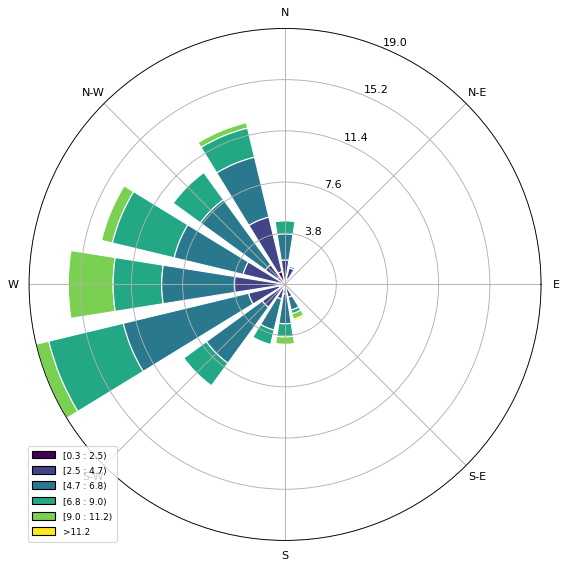

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt
from windrose import WindroseAxes

# Load the DFS2 file
filename = r"D:\Phd Research\Data\Wind data\Winddata_1943_sep.dfs2"  # Replace with your actual file path
dfs2 = mikeio.open(filename)
# Set the item indices for U and V wind components (or wind speed and direction)
u_item_index = 0  # Replace with the correct index for U-component
v_item_index = 1  # Replace with the correct index for V-component

# Read data from the DFS2 file
ds = dfs2.read(items=[u_item_index, v_item_index])

# Extract U and V wind components from the dataset (assuming they are time-series over a grid)
u_data = ds[0].to_numpy()  # Time x Grid for U-component
v_data = ds[1].to_numpy()  # Time x Grid for V-component

# For simplicity, let's extract wind data at a specific grid point (e.g., grid point at [lat, lon] = (0, 0))
# You can select another point or an average across a region
u_at_point = u_data[:, 5, 9]  # U-component at grid point (replace indices with your actual point)
v_at_point = v_data[:, 5, 9]  # V-component at grid point

# Calculate wind speed and direction
wind_speed = np.sqrt(u_at_point**2 + v_at_point**2)
wind_direction = (np.arctan2(u_at_point, v_at_point) * (180 / np.pi)) % 360  # Convert to degrees (0-360)

# Plot the wind rose
ax = WindroseAxes.from_ax()
ax.bar(wind_direction, wind_speed, normed=True, opening=0.8, edgecolor='white')
ax.set_legend()

plt.show()
